<a href="https://colab.research.google.com/github/ErshovKirill/KCVD/blob/main/%D0%9B%D0%B0%D0%B1%D0%BE%D1%80%D0%B0%D1%82%D0%BE%D1%80%D0%BD%D0%B0_%D1%80%D0%BE%D0%B1%D0%BE%D1%82%D0%B0_7_%D0%84%D1%80%D1%88%D0%BE%D0%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Додаємо шум
def add_noise(img, noise_factor=0.5):
    noisy = img + noise_factor * torch.randn_like(img)
    noisy = torch.clip(noisy, 0., 1.)
    return noisy

# DataLoader з шумом
class NoisyMNIST(torch.utils.data.Dataset):
    def __init__(self, dataset):
        self.dataset = dataset

    def __getitem__(self, idx):
        clean_img, _ = self.dataset[idx]
        noisy_img = add_noise(clean_img)
        return noisy_img, clean_img

    def __len__(self):
        return len(self.dataset)

train_loader = DataLoader(NoisyMNIST(train_dataset), batch_size=128, shuffle=True)
test_loader = DataLoader(NoisyMNIST(test_dataset), batch_size=128, shuffle=False)


100%|██████████| 9.91M/9.91M [00:00<00:00, 41.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.18MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.10MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.23MB/s]


In [ ]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 64)
        )
        self.decoder = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 28*28),
            nn.Sigmoid(),
            nn.Unflatten(1, (1, 28, 28))
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


In [ ]:
num_epochs = 10
train_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for noisy_imgs, clean_imgs in train_loader:
        noisy_imgs = noisy_imgs.to(device)
        clean_imgs = clean_imgs.to(device)

        outputs = model(noisy_imgs)
        loss = criterion(outputs, clean_imgs)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")


Epoch [1/10], Loss: 0.0562
Epoch [2/10], Loss: 0.0306
Epoch [3/10], Loss: 0.0259
Epoch [4/10], Loss: 0.0231
Epoch [5/10], Loss: 0.0212
Epoch [6/10], Loss: 0.0199
Epoch [7/10], Loss: 0.0190
Epoch [8/10], Loss: 0.0183
Epoch [9/10], Loss: 0.0177
Epoch [10/10], Loss: 0.0173


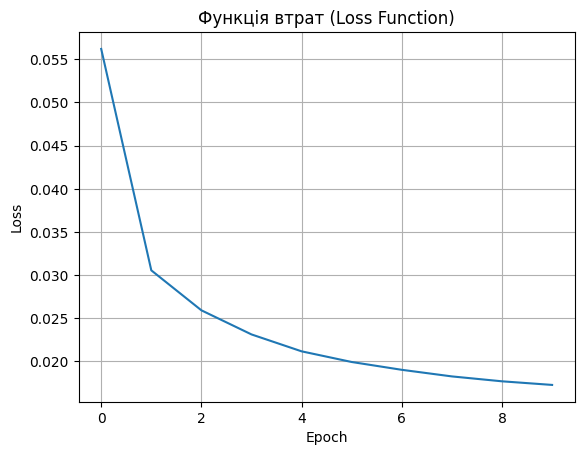

In [ ]:
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Функція втрат (Loss Function)")
plt.grid(True)
plt.show()


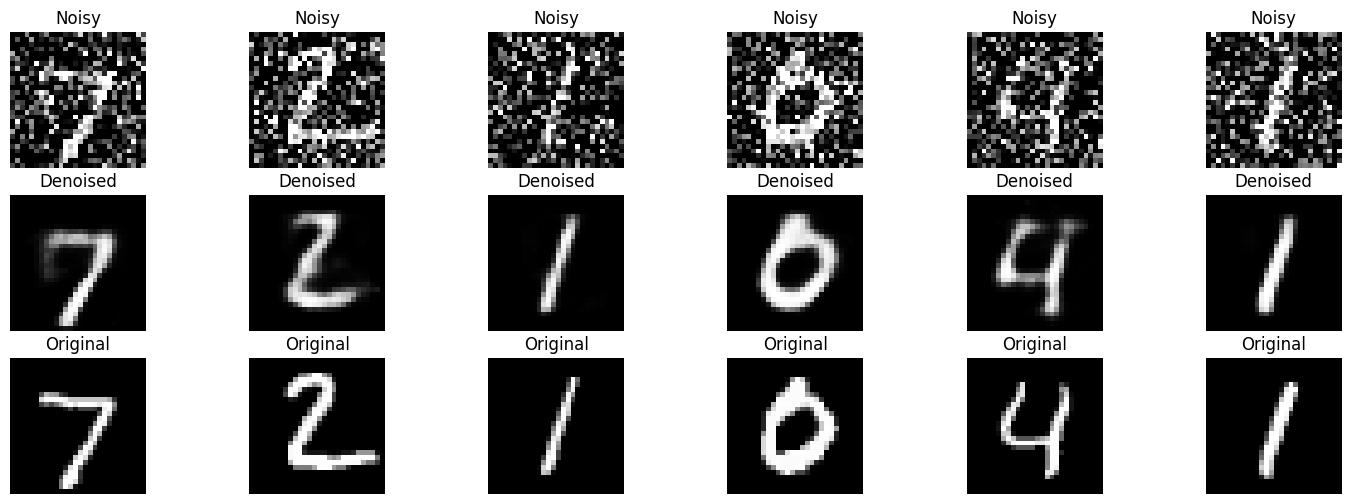

In [ ]:
model.eval()
with torch.no_grad():
    noisy_imgs, clean_imgs = next(iter(test_loader))
    noisy_imgs = noisy_imgs.to(device)
    clean_imgs = clean_imgs.to(device)
    outputs = model(noisy_imgs)

# Виведення перших 6 прикладів
n = 6
plt.figure(figsize=(18, 6))
for i in range(n):
    # noisy
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(noisy_imgs[i].cpu().squeeze(), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # denoised
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(outputs[i].cpu().squeeze(), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

    # original
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(clean_imgs[i].cpu().squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis('off')
plt.show()
